# <font color="steelblue">Visualización de datos con Seaborn</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color='steelblue'>Introducción</font>

**Descripción:** En este cuaderno introducimos la biblioteca *Seaborn* para la representación de datos estadísticos. Reproducimos los gráficos que ya conseguimos previamente con *matplotlib* y descubrimos la versatilidad y facilidad que ofrecen sus funciones para la representación de datos de cualquier tipo y la indagación de relaciones entre más de tres variables, numéricas y categóricas. Aprendemos también a construir gráficos de puntos en tres dimensiones con el módulo `mplot3d` de la librería `mpl_toolkits`.


## <font color='steelblue'> Objetivos de aprendizaje

* Descubrir las funcionalidades de la librería *Seaborn* para la representación de datos univariantes.

* Descubrir las funcionalidades de la librería *Seaborn* para indagar la relación entre dos variables de cualquier tipo.

* Descubrir las funcionalidades de la librería *Seaborn* para indagar la relación entre tres variables de cualquier tipo.

* Aprender a construir gráficos tridimensionales con la librería `mpl_toolkits`.

* Descubrir las funcionalidades de la librería *Seaborn* para indagar la relación entre más de tres variables de cualquier tipo.

## <font color='steelblue'> Contenidos </font>

1. Introducción a Seaborn
1. Relaciones bivariadas
1. Relaciones trivariadas: Num vs Num vs Cat
1. Relaciones trivariadas: Num vs Cat vs Cat
1. Relaciones trivariadas: Num vs Num vs Num
1. Relaciones trivariadas: Cat vs Cat vs Cat
1. Relaciones múltiples


## <font color='steelblue'> 1. Introducción a Seaborn

En cuadernos previos hemos utilizado la librería *matplotlib* para representar información en general, e indagar relaciones entre variables. Sin embargo, existe una librería en Python especialmente diseñada para la visualización de datos estadísticos; esta librería es *Seaborn*.

*Seaborn* es una librería de visualización de datos de **Python** basada en *matplotlib*. Nos proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos, de un modo sencillo e intuitivo. Además, *matplotlib* sigue siendo útil para incorporar complementos y configuraciones gráficas en los gráficos que generamos con *seaborn* (como definir el tamaño de la ventana gráfica, distribuir varios gráficos en una ventana, añadir títulos, leyendas, etc.).

En este cuaderno vamos a mostrar algunas opciones sencillas de Seaborn para realizar el descriptivo gráfico de diversas variables en función de su tipo (numérico o categórico). Procederemos, como siempre, mostrando cómo construir gráficos que nos muestran la distribución de una única variable, y seguimos introduciendo más variables para investigar las relaciones entre dos, tres e incluso más variables. Presentamos las funciones de graficado y sus opciones en función del tipo de variables a representar, donde *Num* se referirá a una variable numérica y *Cat* a una categórica.

*Seaborn* trabaja siempre con *dataframes*, que son introducidos generalmente como primer argumento en las diversas funciones, y a continuación, en el resto de argumentos `x`, `y`, `hue`, ..., asigna, entrecomillados, los nombres de las variables a representar. Para evitar mensajes añadidos en los gráficos, se utiliza el punto y coma `;` inmediatamente después de la llamada a la función de interés.

En ocasiones utilizaremos la función `plt.show()` como veníamos haciendo, para visualizar los gráficos que creamos con *seaborn*, si bien no suele ser necesario y en ocasiones prescindimos de ella.

Para ampliar información sobre *Seaborn* y consultar diversas opciones de visualización y tipos de gráficos, se recomienda visitar el [tutorial de Seaborn](https://seaborn.pydata.org/).



Para utilizar *Seaborn* basta importarla, pues viene preinstalada, e importamos también las librerías *Pandas*, *NumPy* y *matplotlib*. Ejecutamos el código "mágico" de *matplotlib*, `%matplotlib inline`, para conseguir que los gráficos se muestren directamente en el cuaderno.


In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
#@title <font color="steelblue" size="+1"> Descarga de ficheros de datos { display-mode: "form" }

# Descarga de ficheros
!wget {f"https://raw.githubusercontent.com/ia4legos/Statistics/main/data/encuesta_nutricion_cv4.csv"}

--2025-01-23 12:27:51--  https://raw.githubusercontent.com/ia4legos/Statistics/main/data/encuesta_nutricion_cv4.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133580 (130K) [text/plain]
Saving to: ‘encuesta_nutricion_cv4.csv’

encuesta_nutricion_ 100%[===================>] 130.45K  --.-KB/s    in 0.03s   

2025-01-23 12:27:51 (4.02 MB/s) - ‘encuesta_nutricion_cv4.csv’ saved [133580/133580]



Leemos también la base de datos que utilizaremos en este cuaderno, `encuesta_nutricion_cv4.csv`, con las variables numéricas `edad`, `peso`, `talla` y `bmi`, y con las variables categóricas `sexo`, `provincia`, `dni`, `fecha_nacimiento`, `bmi_agrupado` y `bmi_agrupado2`.

In [ ]:
encuesta = pd.read_csv("encuesta_nutricion_cv4.csv", sep=",")
encuesta.head()

,edad,peso,talla,sexo,provincia,dni,fecha_nacimiento,bmi,bmi_agrupado,bmi_agrupado2
0,18,66.4,1.635,HOMBRE,CASTELLÓN,13184786H,2/11/2002,24.84,Normal,Normal
1,18,68.7,1.720,HOMBRE,CASTELLÓN,37707523O,24/4/2002,23.22,Normal,Normal
2,24,76.7,1.700,HOMBRE,ALICANTE,18338426W,22/11/1996,26.54,Sobrepeso,Sobrepeso
3,17,55.6,1.600,MUJER,CASTELLÓN,64334663L,16/4/2003,21.72,Normal,Normal
4,16,46.6,1.635,MUJER,CASTELLÓN,45309142X,21/9/2004,17.43,Infrapeso,Infrapeso


### <font color='steelblue'> Gráficos univariantes

Las funciones de *Seaborn* con las que representar la distribución de una variable, esto es, mostrar cómo se reparten los datos disponibles, son:
- para variables categóricas la función **`countplot()`** proporciona diagramas de barras sin necesidad de calcular la tabla de frecuencias;
- para variables numéricas la función **`histplot()`** genera histogramas, **`boxplot()`** diagramas de cajas y bigotes, y **`violinplot()`** gráficos de violín.

La función **`displot()`** es multifuncional y por defecto genera histogramas cuando la variable introducida es de tipo numérico, y diagrama de barras cuando es de tipo categórico. También puede crear otro tipo de gráficos.

Todas estas funciones reciben como argumentos:
```
(data=df, x='var_num')
```
donde `df` es el nombre del dataframe en el que se encuentra la variable numérica a representar `var_num`.

Se recomienda consultar las ayudas específicas de estas funciones en el tutorial de Seaborn: [countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html), [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn-histplot), [boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html#seaborn.boxplot),[violinplot](https://seaborn.pydata.org/generated/seaborn.violinplot.html#seaborn-violinplot) y [displot](https://seaborn.pydata.org/generated/seaborn.displot.html) .


Aplicamos estas funciones a nuestra base de datos, para mostrar cómo operan con las variables `sexo` (categórica) y `talla` (numérica).

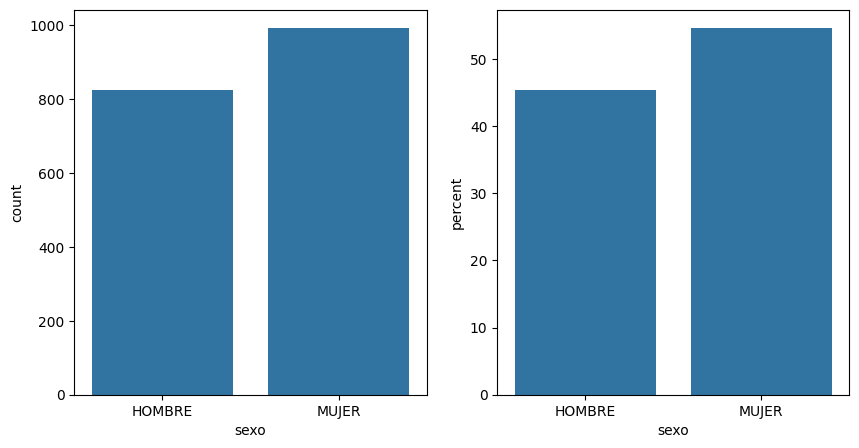

In [ ]:
# Diagrama de barras para una variable categórica (conteos)
plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
sns.countplot(encuesta, x="sexo");
# Diagrama de barras para una variable categórica (porcentajes)
plt.subplot(1,2,2)
sns.countplot(encuesta, x="sexo",stat="percent");

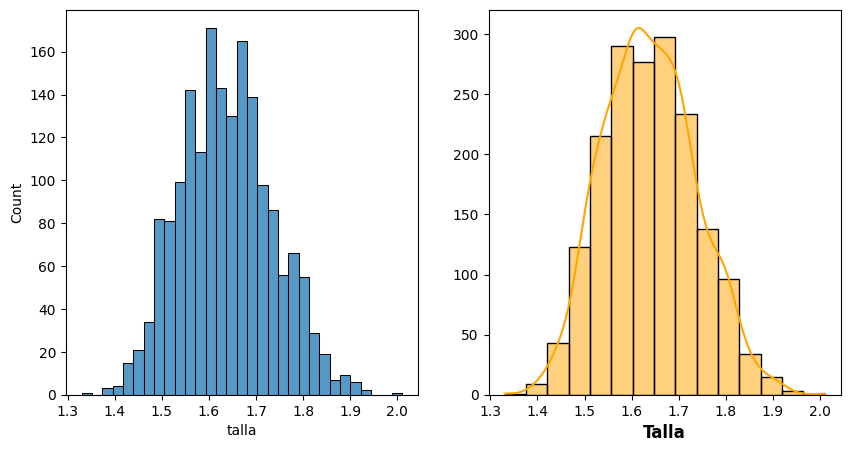

In [ ]:
# Distribución de variables numéricas
plt.figure(figsize = [10, 5])

# Histograma de una variable numérica con histplot()
plt.subplot(1,2,1) # izquierda
sns.histplot(encuesta,x="talla");

# el mismo histograma con otras opciones de visualización
plt.subplot(1,2,2) # derecha
sns.histplot(encuesta,x="talla",color="orange",bins=15,kde=True);
#kde=True añade una curva de suavizado
plt.xlabel("Talla",fontweight='bold',fontsize=12)
plt.ylabel("")
plt.show()

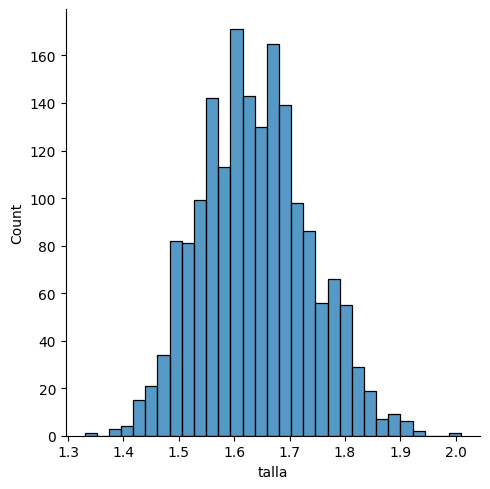

In [ ]:
# Histograma con displot
sns.displot(encuesta,x="talla");

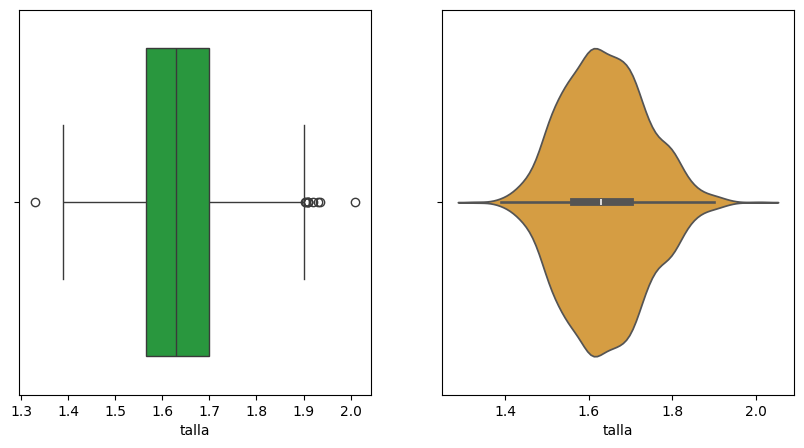

In [ ]:
# Distribución de variables numéricas
plt.figure(figsize = [10, 5])
# Gráfico de cajas
plt.subplot(1,2,1)
sns.boxplot(encuesta,x="talla",color='#17A932');

# Gráfico de violín
plt.subplot(1,2,2)
sns.violinplot(x='talla', data=encuesta,color='#EDA32B');

## <font color='steelblue'> 2. Relaciones bivariadas

Proponemos a continuación cómo investigar relaciones entre dos variables en función de su tipo. Así planteamos opciones cuando la relación a investigar es:

- **Num vs Num** (dos variables numéricas), esto es, se investiga cómo varía una variable cuando también varía la otra, tendencias, .... Un ejemplo puede ser investigar la relación entre la `talla` y el `bmi` en nuestra base de datos.
- **Cat vs Cat** (dos variables categóricas), cuando ambas variables categóricas, para indagar si los repartos de datos son similares en las diferentes combinaciones de respuestas o siguen algún patrón específico. Un ejemplo en nuestra base de datos es estudiar la relación entre `sexo` y `provincia`.
- **Num vs Cat** (una variable numérica y otra categórica), esto es, investigar si cierta variable numérica manifiesta un comportamiento similar en todas las categorías de respuesta de otra variable categórica de clasificación. Un ejemplo es investigar la relación entre `sexo` y `bmi` en nuestra 'encuesta'.


### <font color='steelblue'> Gráficos de dispersión: Num vs Num

Para obtener un gráfico de dispersión con dos variables numéricas, basta con utilizar cualquiera de las funciones siguientes:
- **`sns.scatterplot()`** genera una nube de puntos;

- **`sns.regplot()`** o **`sns.lmplot()`**, generan una nube de puntos con una recta interpolante sobre los puntos, para mostrar si la tendencia entre las variables es de tipo lineal;

- **`sns.jointplot()`**, genera una nube de puntos con los histogramas de las variables en los ejes

-  **`sns.relplot()`** es una función genérica que permite obtener gráficos de dispersión por defecto (con el argumento `kind='scatter'`), y otros.

Todas estas funciones utilizan como argumentos básicos:
```
(data = df, x = 'num_var1', y = 'num_var2')
```
donde `data=df` hace referencia al dataframe que contiene toda la información, `num_var1` es el nombre de la variable que se representa en el eje X, y `num_var2` el de la que se representa en el eje Y.

Para ampliar información sobre estas funciones se recomienda consultar el tutorial de Seaborn: [scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html#seaborn-scatterplot), [regplot](https://seaborn.pydata.org/generated/seaborn.regplot.html), [lmplot](https://seaborn.pydata.org/generated/seaborn.lmplot.html), [jointplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html#seaborn-jointplot).

Representamos a continuación la relación entre las variables numéricas `peso` y `bmi` utilizando todas estas opciones.

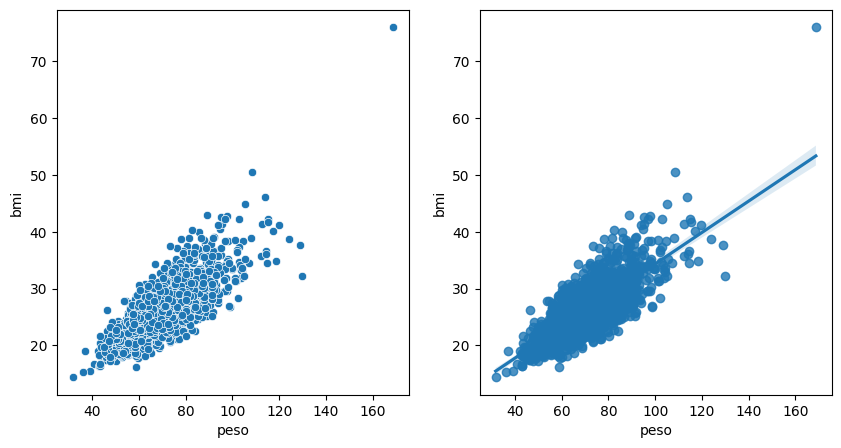

In [ ]:
# Gráficos de dispersión con scatterplot y regplot
plt.figure(figsize = [10, 5])
plt.subplot(1,2,1)
sns.scatterplot(encuesta,x="peso",y="bmi");
plt.subplot(1,2,2)
sns.regplot(encuesta,x="peso",y="bmi");


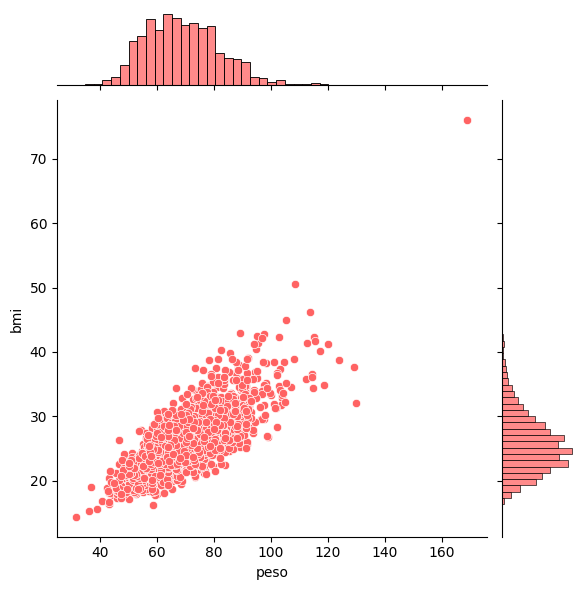

In [ ]:
# Gráfico de dispersión e histogramas
sns.jointplot(encuesta,x="peso",y="bmi",color="#FF6363");

La función genérica **`sns.relplot()`** proporciona gráficos de dispersión pero permite obtener también gráficos de líneas con `kind='line'`, cuando interesa investigar la evolución a lo largo del tiempo o de alguna variable ordenada (como en las series temporales).  

Cuando utilizamos la función `relplot()` podemos considerar como argumentos gráficos complementarios:

- `style`, permite configurar la forma de los puntos;
- `size` permite configurar el tamaño de los puntos;
- `height` es un entero que indica la altura del gráfico;  
- `aspect=1` indica la relación *ancho/alto* del gráfico (el denominador ha de coincidir con el valor de `height` si se introduce un cociente; si queremos que el ancho sea el doble de la altura, bastará con utilizar `aspect=2`);
- `palette` permite especificar la paleta de colores a utilizar ([consultar paletas](https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette)).

Con la extensión `.set()` se añaden títulos y etiquetas al gráfico (con los argumentos `title`, `xlabel`,`ylabel`). Con el fin de facilitar que la sintaxis se muestre clara, podemos optar por generar el gráfico y asignarlo a un objeto, y a continuación añadir las etiquetas añadiendo `.set()` a dicho objeto.

Vamos a utilizar esta función para mostrar la relacióon entre `peso` y `bmi`, cambiando el color y tamaño de los puntos, excluyendo leyenda, y añadiendo etiquetas para ejes y título.

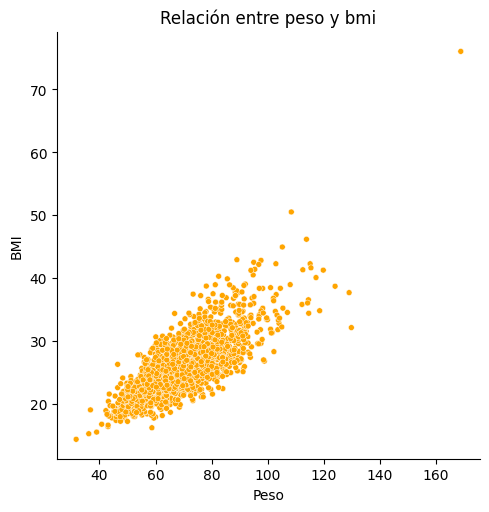

In [ ]:
# Gráfico de dispersión con relplot
#  Cambiamos color, dimensionamos los puntos y evitamos la leyenda
g=sns.relplot(encuesta,x="peso",y="bmi",color="orange",size=2,legend=False);
g.set(title="Relación entre peso y bmi",xlabel='Peso',ylabel='BMI');

Anteponiendo la función **`sns.set_style()`** podemos configurar el estilo del gráfico con diferentes temas, como `whitegrid`, `darkgrid`, `"dark"`, `"white"` o `"ticks"` e incluso modificar estos estilos con argumentos específicos para los colores de fondos y líneas. El estilo que se emplea por defecto es `"ticks"`. Probamos a continuación con `whitegrid`.

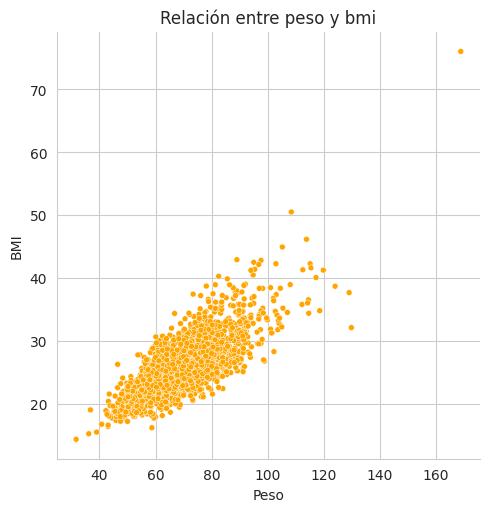

In [ ]:
# Estilo del gráfico
sns.set_style("whitegrid")
g=sns.relplot(encuesta,x="peso",y="bmi",color="orange",size=2,legend=False);
g.set(title="Relación entre peso y bmi",xlabel='Peso',ylabel='BMI');

Para saber más sobre la personalización de gráficos en Seaborn, se recomienda consultar el [tutorial de asthetics](https://seaborn.pydata.org/tutorial/aesthetics.html).

**Nota:** si no volvemos a utilizar la función `set_style`, el gráfico se muestra con el último estilo que se haya indicado. Para retornar al original es preciso especificar `sns.set_style("ticks")`.

In [ ]:
# Formatear el estilo original de los gráficos
sns.set_style("ticks")

### <font color='steelblue'> Gráficos de barras por grupos: Cat vs Cat

Cuando indagamos la relación entre dos variables categóricas `cat_var1` y `cat_var2`, utilizamos las tablas de frecuencias con los conteos en cada una de las combinaciones que surgen al combinar sus posibles respuestas. Con *Seaborn* no tenemos que calcular las tablas de frecuencias y podemos representarlas directamente con las funciones **`countplot()`** y la multifuncional **`displot()`**. Para reproducir los gráficos que obtuvimos en cuadernos previos tenemos las opciones:

1. para conseguir **gráficos de barras distintos** para `cat_var1`, dispuestos por columnas para cada nivel de `cat_var2`:
```
sns.displot(data=df,x = 'cat_var1', hue = 'cat_var1',col='cat_var2', col_order)
```

1. para obtener un **único gráfico de barras**, diferenciando las barras con colores para distinguir los niveles de `cat_var2`:
```
sns.countplot(data = df, x = 'cat_var1', hue = 'cat_var2',hue_order)
```

1. para crear un gráfico de **barras apiladas**, diferenciando con colores los niveles de `cat_var2`:
```
sns.displot(data=df,x='cat_var1',hue='cat_var1',hue_order,multiple="stack")
```


El argumento **`hue`** identifica la variable respecto de la que establecer la clave de color, esto es, la diferenciación por colores. El argumento **`col`** identifica la variable respecto de la que construir gráficos distintos para cada nivel y después los distribuye por columnas.

Los argumentos `hue_order` y `col_order` han de recibir la asignación de una lista con el orden deseado para las variables utilizadas respectivamente en `hue` y `col`.

Veamos el resultado de aplicar estas funciones a la relación entre `sexo` y `provincia` de nuestra base de datos.

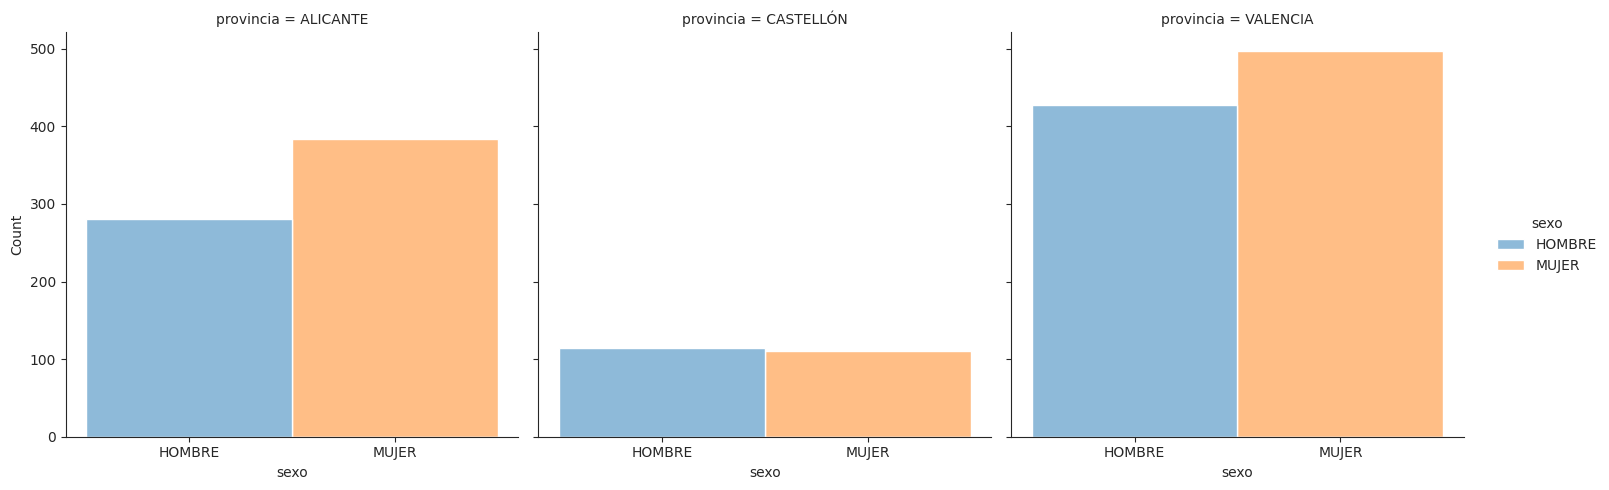

In [ ]:
# Distribución de 'sexo' por 'provincia'. Gráficos de barras

# Opción 1. Gráficos distintos para cada provincia, distribuidos por columnas
sns.displot(encuesta,x="sexo",hue="sexo",col='provincia',
            col_order=["ALICANTE","CASTELLÓN","VALENCIA"]);


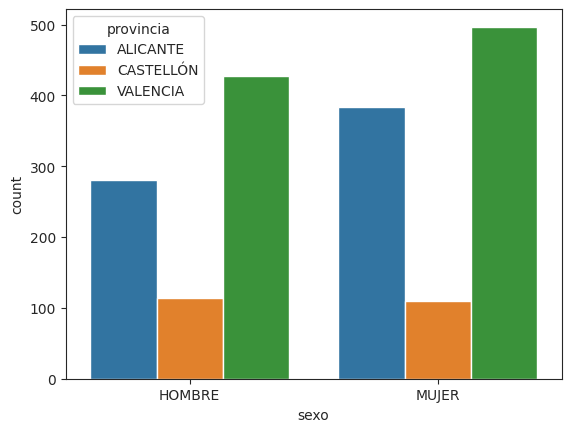

In [ ]:
# Distribución de 'sexo' por 'provincia'. Gráficos de barras

# Opción 2. Un único gráfico, diferenciando por colores las provincias
sns.countplot(encuesta,x="sexo",hue="provincia",hue_order=["ALICANTE","CASTELLÓN","VALENCIA"]);

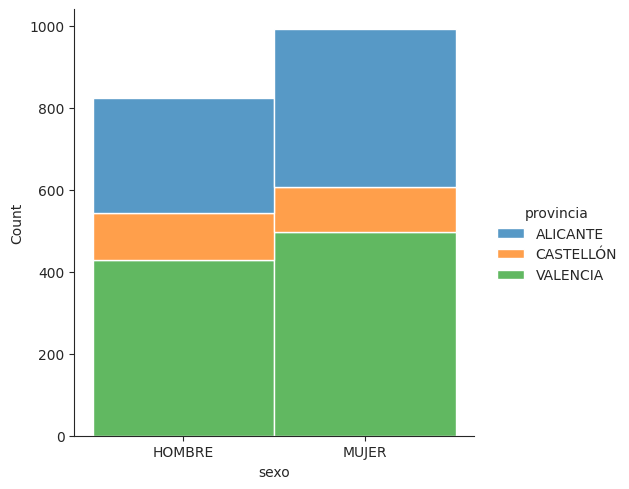

In [ ]:
# Distribución de 'sexo' por 'provincia'. Gráfico de barras apiladas

# Opción 3. Barras apiladas, diferenciando por colores las provincias
sns.displot(encuesta,x="sexo",hue="provincia",
            hue_order=['ALICANTE','CASTELLÓN','VALENCIA'],multiple="stack");

### <font color="steelblue"> Gráficos de cajas por grupos: Num vs Cat

Para investigar si cierta variable categórica `cat_var` está relacionada con otra numérica `num_var`, mostramos esta última en cada uno de los niveles de la primera, a través de gráficos de cajas, y los comparamos. Esto lo conseguimos aprovechando las funciones específicas para crear gráficos de cajas y violines, como
- **`sns.boxplot()`** y
- **`sns.violinplot()`**.

Además, existen funciones relacionales como:  
- **`sns.catplot(..., kind='box')`**, que proporciona gráficos de cajas ([consultar tutorial](https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot));
- **`sns.pointplot(...,errorbar='sd')`**, que representa con puntos las medias en cada nivel de la variable categórica, y prolonga barras de error con la desviación típica ([completar información](https://seaborn.pydata.org/generated/seaborn.pointplot.html#seaborn.pointplot));
- **`sns.stripplot(...)`**, que representa todos los puntos de la variable numérica en cada nivel de la categórica ([completar información](https://seaborn.pydata.org/generated/seaborn.stripplot.html#seaborn.stripplot)).

Todas estas funciones incorporan como argumentos básicos
```
(data = df, x = 'cat_var', y = 'num_var')
# si bien pueden intercambiar ejes
(data = df, x = 'num_var', y = 'cat_var')
```
Además podemos incorporar una clave de color con el argumento `hue`.

Veamos cómo implementar estos gráficos para investigar la relación entre `bmi` y `provincias` y responder la pregunta: ¿son similares las provincias respecto al `bmi` de su población?


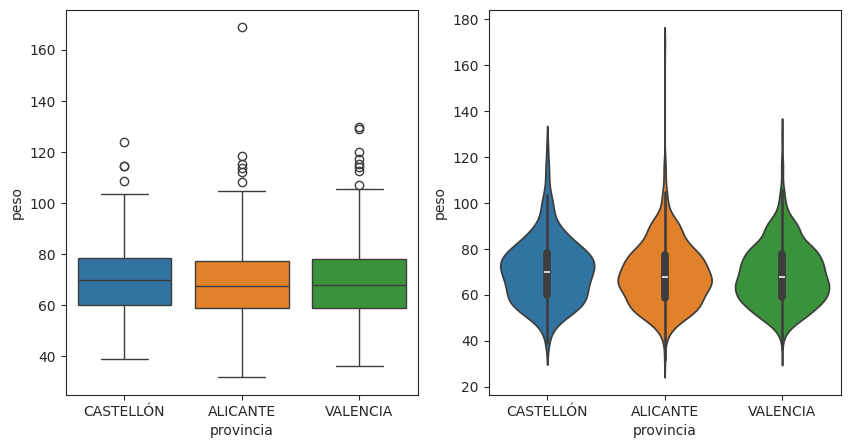

In [ ]:
# Gráficos de cajas y violines de peso diferenciando por provincias
plt.figure(figsize = [10, 5])
plt.subplot(1, 2, 1)
sns.boxplot(encuesta, x = 'provincia', y = 'peso', hue='provincia');
plt.subplot(1, 2, 2)
sns.violinplot(encuesta, x = 'provincia', y = 'peso', hue='provincia');

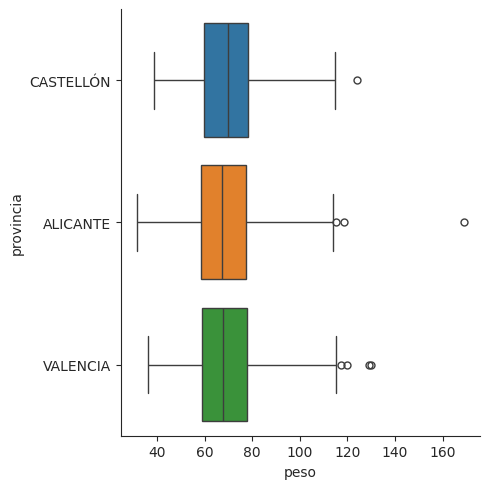

In [ ]:
# Diagramas de cajas relacionales: Num vs Cat
# Comparación del `bmi` por provincias.
sns.catplot(x = "peso", y = "provincia", hue='provincia',
            data = encuesta, kind = "box",  whis = 2);

**Nota**. Las funciones multifuncionales que proporcionan distintos tipos de gráficos, como `catplot()` o `displot()` no responden a configuraciones de ventana gráfica, como la que pretendemos en ocasiones con `plt.sublplot()`.

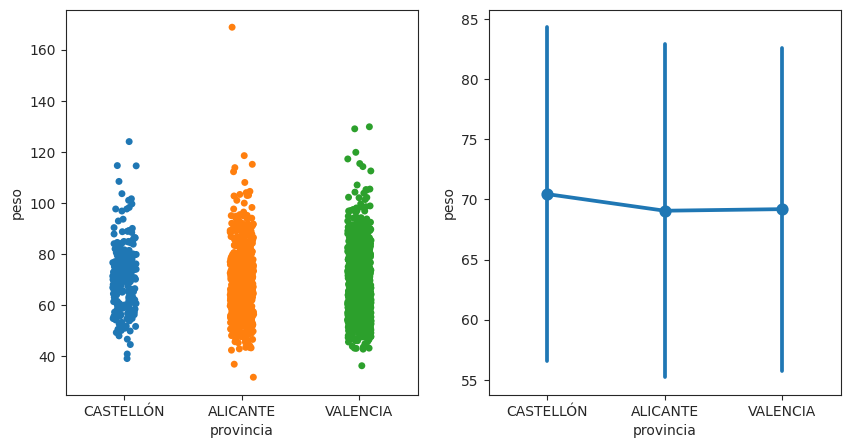

In [ ]:
# Diagramas de cajas relacionales: Num vs Cat
# Comparación del `bmi` por provincias.
plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
sns.stripplot(y = "peso", x = "provincia", hue='provincia',
              data = encuesta);
plt.subplot(1,2,2)
sns.pointplot(y = "peso", x = "provincia",data = encuesta,
              errorbar='sd');

### <font color='steelblue'> Histogramas por grupos: Num vs Cat

Para representar con histogramas la distribución de una variable numérica en cada uno de los niveles de respuesta de una variable categórica de agrupación, podemos utilizar las funciones:
- **`sns.displot(data=df, x='num_var', col='cat_var',col_order,bins)`**, para generar histogramas separados, uno por cada nivel de respuesta de `cat_var`;

- **`sns.displot(data=df, x='num_var', hue='cat_var',hue_order, bins, stat='density',common_norm=False)`**, para generar histogramas superpuestos, en escala de densidad para hacerlos comparables (con los argumentos `stat='density', common_norm=False`),

donde
`col='cat_var'` define varias columnas en la primera función, y  `hue='cat_var'` define varios colores en la segunda función. Con `col_order` y `hue_order` podemos pasar una lista con el orden de visualización deseado para los niveles de `cat_var`, y con el argumento `bins` el número de barras deseadas.

Vemos pues, los gráficos resultantes para investigar la relación entre `peso` y `provincia`.

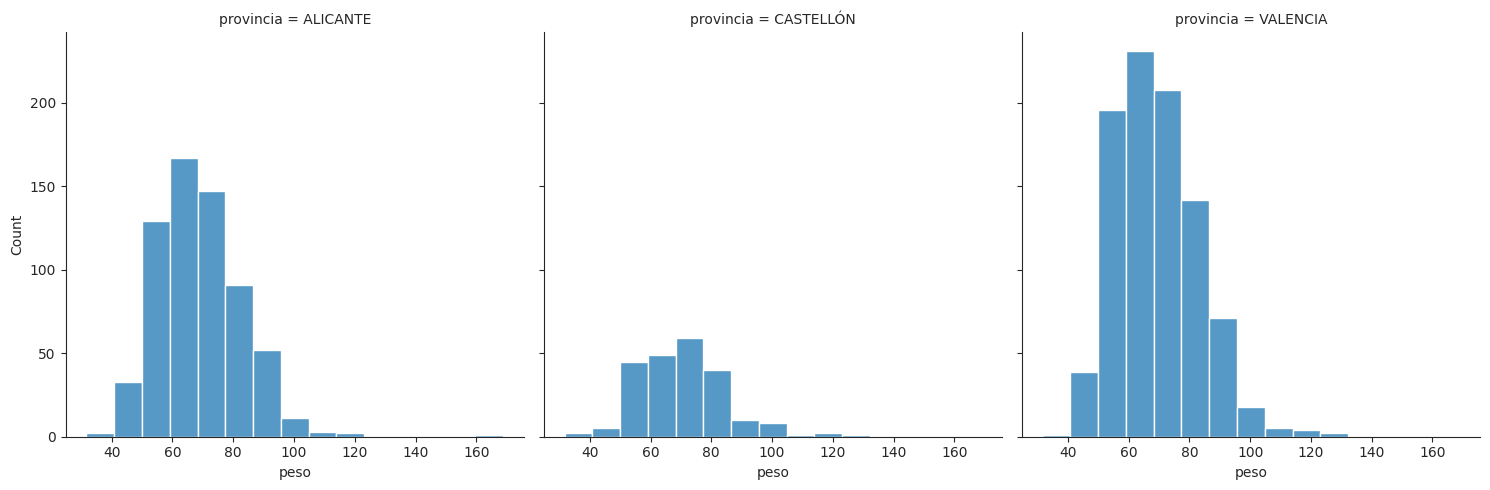

In [ ]:
# Histogramas de peso diferenciados por provincias. Escala absoluta
sns.displot(encuesta, x="peso", col="provincia",
            col_order=["ALICANTE","CASTELLÓN","VALENCIA"],bins=15);

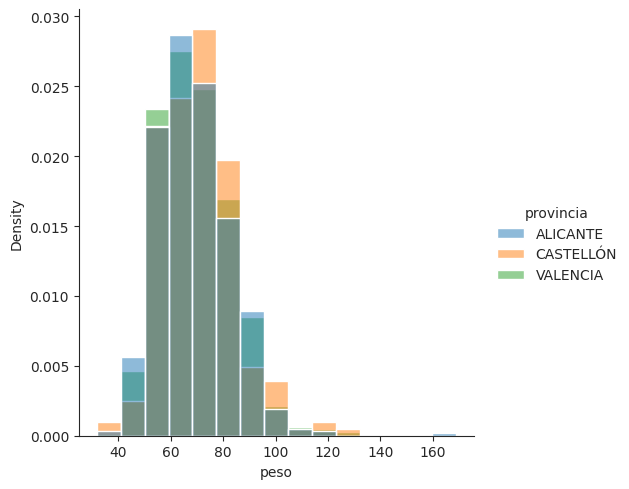

In [ ]:
# Histogramas de peso superpuestos por provincias. Escala densidad
sns.displot(encuesta, x="peso", hue="provincia",
            hue_order=["ALICANTE","CASTELLÓN","VALENCIA"],
            stat="density",common_norm=False,bins=15);

Repasados ya los gráficos univariantes y bivariantes con *Seaborn*, abordamos la generalización a gráficos trivariantes e incluso con más variables, diferenciando representaciones por tipo de variables.

## <font color='steelblue'> 3. Relaciones múltiples

Cuando pasamos de tres variables, seguimos con la misma dinámica para mostrar relaciones entre las variables, y utilizaremos claves de color, de tamaño, facetas en filas y columnas para distribuir distintos gráficos, ....

En este apartado nos vamos a concentrar en mostrar la utilidad de la función **`PairGrid()`**, del módulo *Seaborn*, si bien son muchas las funciones que nos proporciona *Seaborn* para representaciones múltiples. Recomendamos ampliar información en el [tutorial de Seaborn](https://seaborn.pydata.org/generated/seaborn.PairGrid.html).

Esta función está programada para recibir los siguientes argumentos:
- `data`, el dataframe en el que están contenidos los datos,
- `x_vars`, la lista de variables que se muestran por columnas,
- `y_vars`, la lista de variables que se muestran por fila,
- `vars`, una lista con los nombres de las variables a utilizar,

Si prescindimos de los argumentos `x_vars` e `y_vars`, y solo utilizamos `vars`, esta función grafica todos los cruces bivariados de variables especificadas en `vars`.

- `hue`, donde se asigna el nombre de la variable que va a añadir una clave de color,
-  `hue_order`, una lista con la ordenación con que queremos visualizar las categorías de la variable en `hue`.
- `palette`, la paleta de colores a utilizar
- `height`, la altura de cada gráfico o faceta
-  `aspect`, el ratio de ancho/alto de cada faceta,
- `dropna=False/True`, para eliminar los valores faltantes antes de graficar.

Una vez hemos especificado la estructura de los gráficos, esta función representará todas las relaciones bivariadas entre las variables incluidas.

Si estamos especificando un único subconjunto de variables con el argumento `vars`, se crea un entramado con tantas facetas por filas y por columnas como número de variables especificadas. En dicho entramado  especificaremos el tipo de los gráficos en la diagonal y fuera de la diagonal con las extensiones:

- `.map_diag()`, gráficos a incluir en la diagonal,
- `.map_offdiag()`, gráficos a incluir fuera de la diagonal.

Finalmente con la extensión `.fig.suptitle()` añadiremos un título global a todos los gráficos generados, y con `.add_legend()` mostraremos la leyenda con las claves de color en `hue`.





Comenzamos por representar todas las relaciones de una variable numérica con un conjunto de otras numéricas, diferenciando por una variable de clasificación o categórica.

En nuestra base de datos nos interesa representar la relación entre `peso`, que especificamos en `y_vars`, con `talla`, `edad` y `bmi`, todas ellas numéricas, que incorporamos en una lista que asginamos a `x_vars`, diferenciando por `sexo` (categórica) y que asignamos a la clave de color `hue`. Si queremos también visualizar la distribución (univariante) de `peso`, incluimos también esta variable en el listado de `x_vars`.

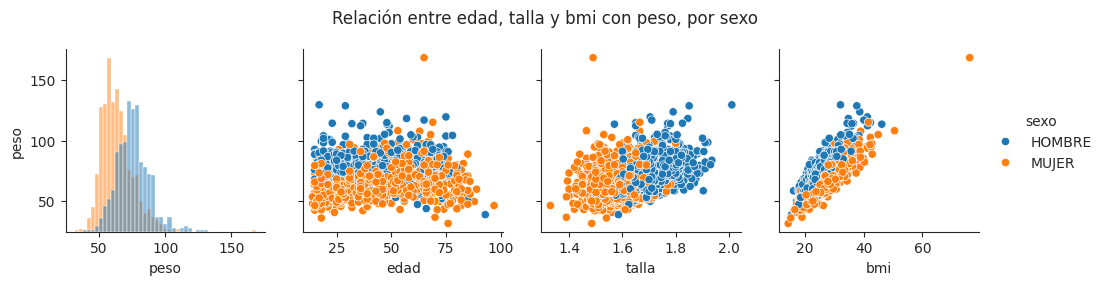

In [ ]:
# Almacenamos las variables en el eje X
variables_x = ["peso", "edad", "talla", "bmi"]
# Almacenamos la variable en el eje Y
variables_y = ["peso"]

# Cuadrículas o facetas: filas=variables_y, columnas=variables_x, color=hue
g= sns.PairGrid(data=encuesta, x_vars=variables_x, y_vars=variables_y, hue="sexo")
# Cuando coincidan las variables fila-columna, se muestra un histograma
g.map_diag(sns.histplot)
# Cuando no coinciden las variables fila-columna, se muestra un gráfico de dispersión
g.map_offdiag(sns.scatterplot)

# Añadimos un título al conjunto de gráficos
g.fig.suptitle('Relación entre edad, talla y bmi con peso, por sexo', y=1.1)

# Mostramos la leyenda
g.add_legend();

# Mostramos el gráfico
plt.show()

Si queremos mostrar a la vez todas las relaciones entre las variables numéricas, a través de gráficos de dispersión fuera de la diagonal e histogramas en la diagonal, las asignamos al argumento `vars`.


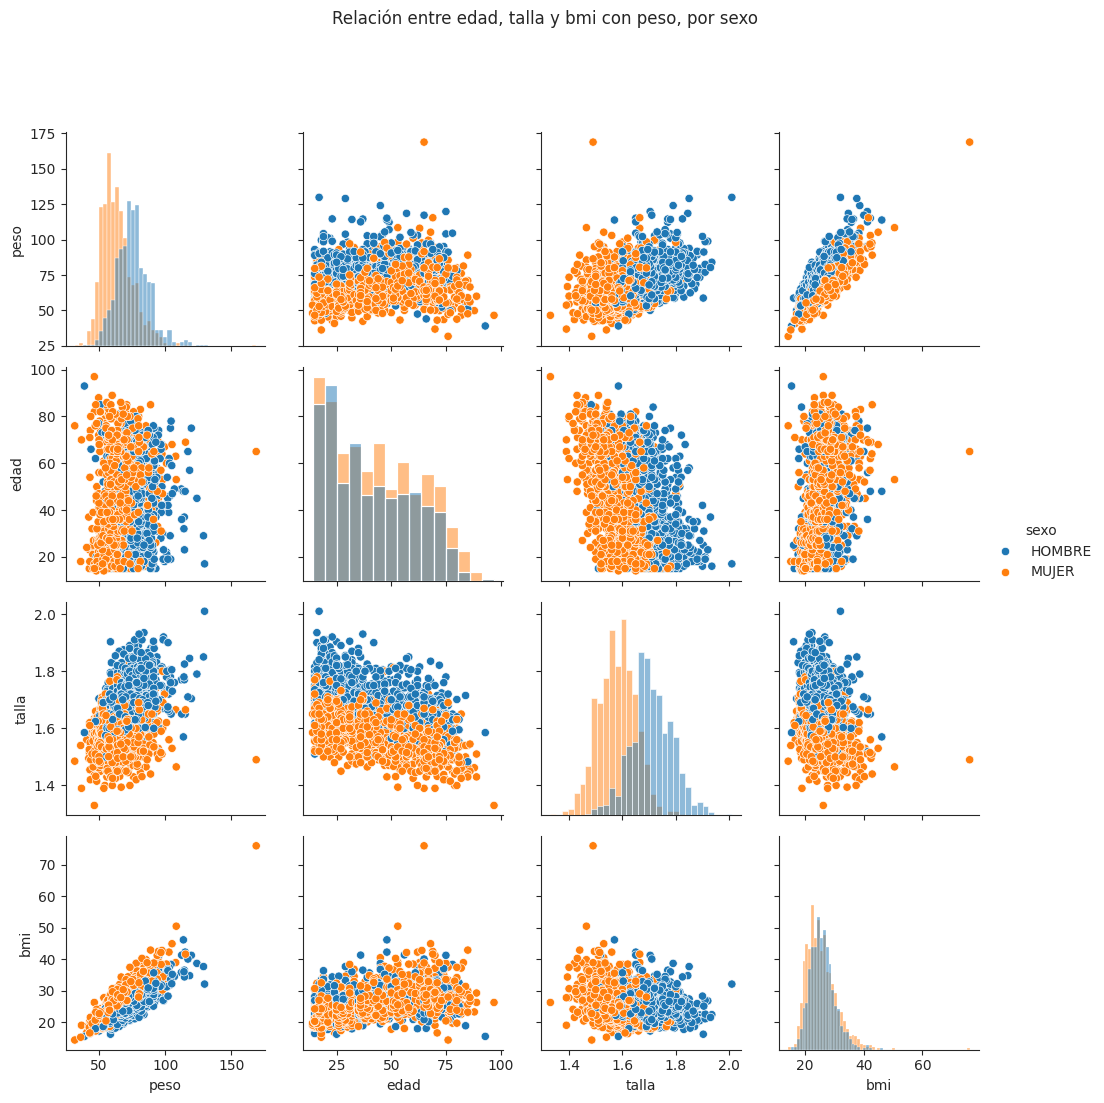

In [ ]:
# Almacenamos todas las variables a relacionar
variables = ["peso", "edad", "talla", "bmi"]

# Cuadrículas o facetas: filas=variables_y, columnas=variables_x, color=hue
g= sns.PairGrid(data=encuesta, vars=variables, hue="sexo")
# Cuando coincidan las variables fila-columna, se muestra un histograma
g.map_diag(sns.histplot)
# Cuando no coinciden las variables fila-columna, se muestra un gráfico de dispersión
g.map_offdiag(sns.scatterplot)

# Añadimos un título al conjunto de gráficos
g.fig.suptitle('Relación entre edad, talla y bmi con peso, por sexo', y=1.1)

# Mostramos la leyenda
g.add_legend();

# Mostramos el gráfico
plt.show()

Puesto que en este gráfico se muestran todos los cruces de variables (por filas y columnas), realmente para extraer conclusiones basta con la diagonal y los gráficos por debajo (o por encima) de ella. Si queremos prescindir del triángulo superior de gráficos, por encima de la diagonal, utilizamos el argumento **`corner=True`** dentro de la función `PairGrid()`.

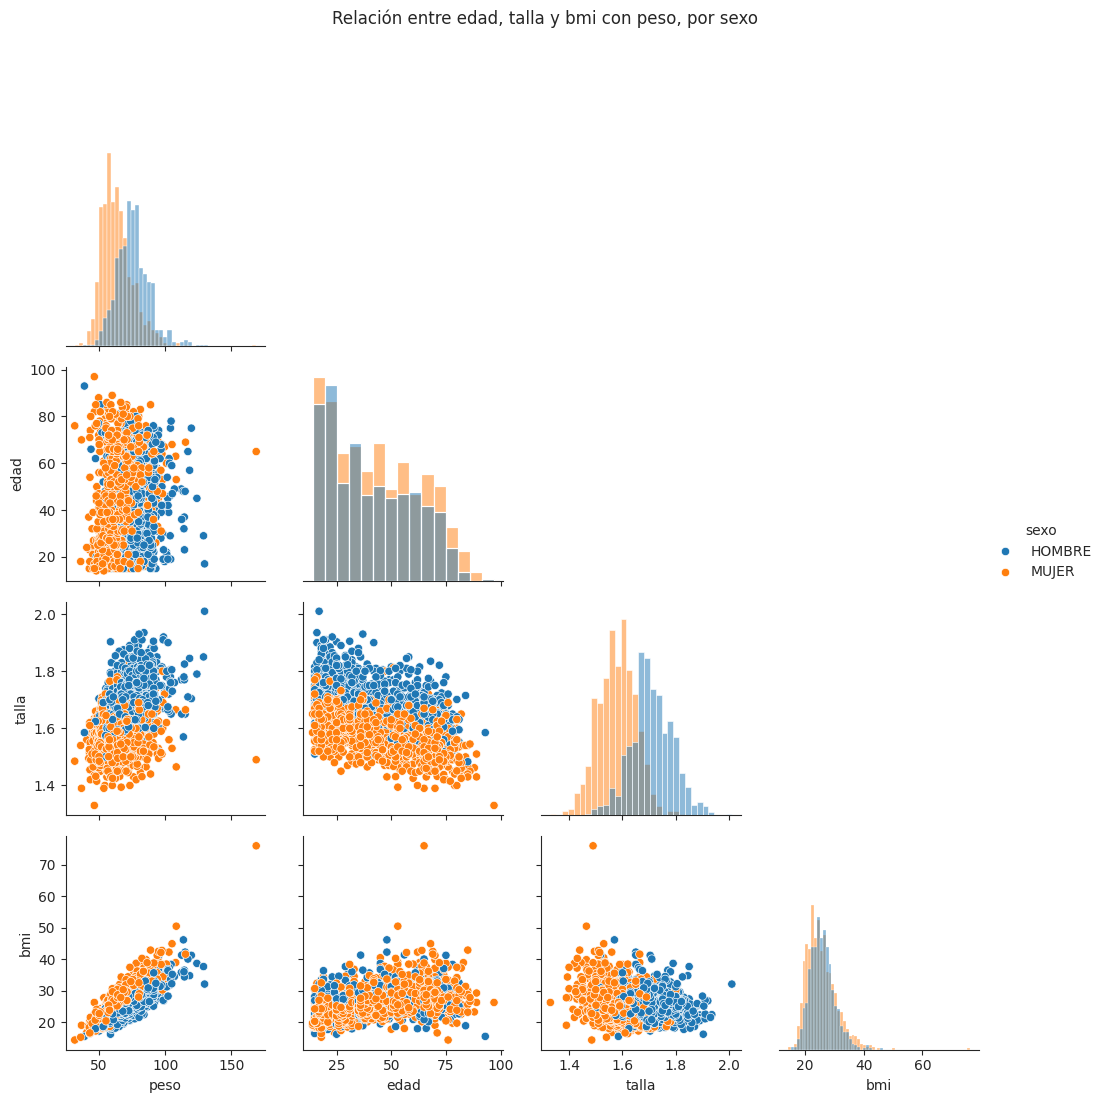

In [ ]:
# Almacenamos todas las variables a relacionar
variables = ["peso", "edad", "talla", "bmi"]

# Cuadrículas o facetas: filas=variables_y, columnas=variables_x, color=hue
g= sns.PairGrid(data=encuesta, vars=variables, hue="sexo",corner=True)
# Cuando coincidan las variables fila-columna, se muestra un histograma
g.map_diag(sns.histplot)
# Cuando no coinciden las variables fila-columna, se muestra un gráfico de dispersión
g.map_offdiag(sns.scatterplot)

# Añadimos un título al conjunto de gráficos
g.fig.suptitle('Relación entre edad, talla y bmi con peso, por sexo', y=1.1)

# Mostramos la leyenda
g.add_legend();

# Mostramos el gráfico
plt.show()

Podemos utilizar esta función para estudiar la relación entre varias variables numéricas  y varias categóricas, a través de diagramas de cajas (boxplots). Para ello, bastaría con asignar en un eje las variables numéricas, y en el otro las categóricas. Podemos seguir incluyendo otra variable categórica como clave de color.

Procedemos representando la relación entre las variables numéricas `peso`, `edad`, `talla`, `bmi`, respecto de las variables categóricas `provincia`, `bmi_agrupado`, `bmi_agrupado2` y `sexo`. Esta última la utilizamos como clave de color.

Puesto que en la diagonal no coinciden las mismas variables, no es preciso especificar qué gráfico utilizar. En los cruces de variables distintas (fuera de la diagonal), con la función `map.offdiag()` indicamos que vamos a utilizar los gráficos `boxplot` de *Seaborn*.

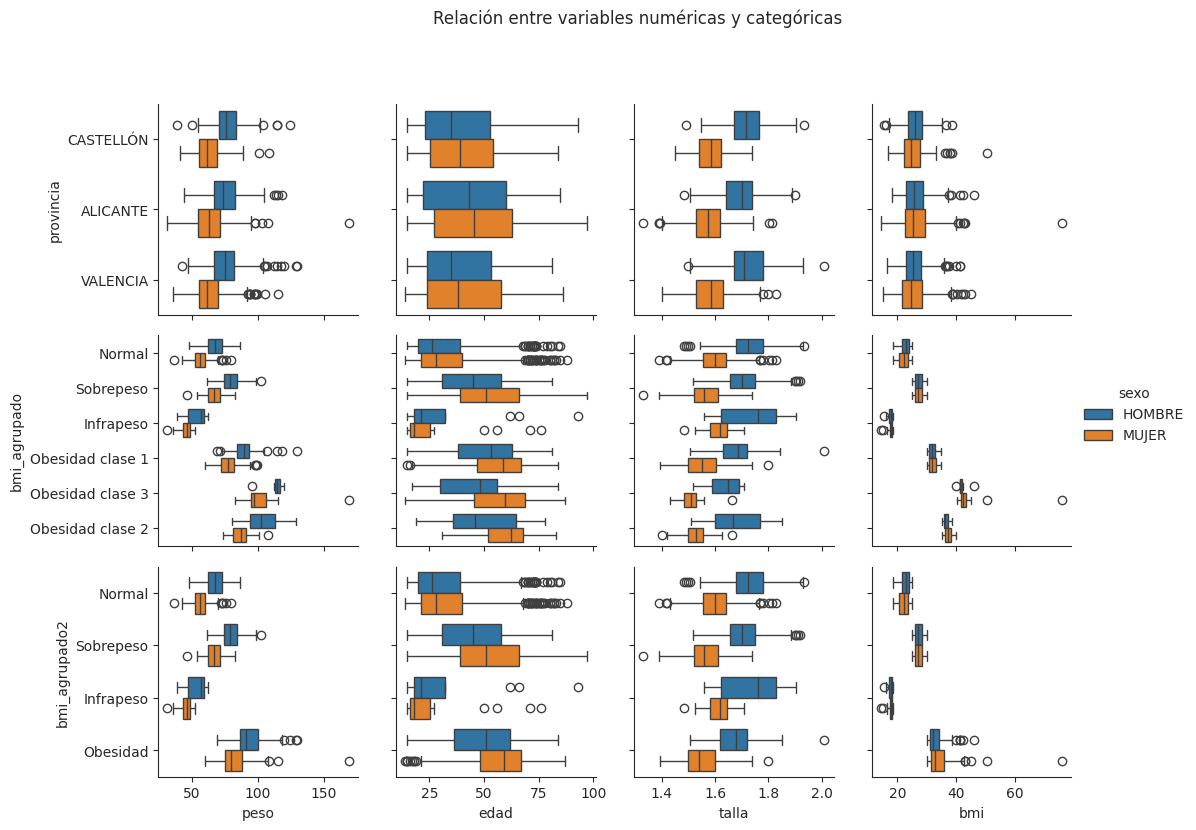

In [ ]:
# Almacenamos las variables numéricas
variables_y = ["provincia", "bmi_agrupado", "bmi_agrupado2"]
# Almacenamos las variables categóricas
variables_x = ["peso", "edad", "talla", "bmi"]

# Cuadrículas o facetas: filas=variables_y, columnas=variables_x, color=hue
g= sns.PairGrid(data=encuesta, x_vars=variables_x, y_vars=variables_y,hue="sexo")
# Cuando no coinciden las variables fila-columna, se muestra un gráfico de dispersión
g.map_offdiag(sns.boxplot)

# Añadimos un título al conjunto de gráficos
g.fig.suptitle('Relación entre variables numéricas y categóricas', y=1.1)

# Mostramos la leyenda
g.add_legend();

# Mostramos el gráfico
plt.show()

Al mostrar las variables categóricas en el eje Y conseguimos una mejor visualización de todas las etiquetas, que se solaparían si se mostraran en el eje X.
